Neurometric response functions relating single-neuron activity to both phonetic content and subsequent behavioral choice.
Compare two neural responses:
1. early phonetic response
2. late feedback response
in the same electrodes.

In [1]:
from pathlib import Path
import re
from typing import Any, TypeAlias

from loguru import logger as L
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import polars as pl
import polars_ds as pds
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
import seaborn as sns
import torch
from tqdm.auto import tqdm
tqdm.pandas()

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from src.data import add_metadata_features
from src.stimuli import OFFSET_DICT, POD_dict

In [4]:
sns.set_context("paper", font_scale=2)

In [82]:
all_epochs = list(Path("outputs/epochs_preprocessed").glob("*_epo.fif"))

# Behavioral decoding searchlight
A_behav_predictions = list(Path("outputs/causal4/behavior_decoding_single_electrode_summarize").glob("*/A-predictions.parquet"))
A_early_behav_predictions = list(Path("outputs/causal4/behavior_decoding_single_electrode_summarize").glob("*/A_early-predictions.parquet"))

# phonetic decoding searchlight. NB this is currently only done for behaviorally selective sites
# TODO broaden
phon_predictions_path = Path("outputs/causal4/A_predictions/behavior_to_phonetic_decoding.parquet")

epoch_tmin = -0.4
epoch_sfreq = 100

# parameters for searching for behavioral peaks
behav_response_tmin_min = 0.3
behav_response_tmax_max = 1.3
behav_response_smin_min = (behav_response_tmin_min - epoch_tmin) * epoch_sfreq
behav_response_smax_max = (behav_response_tmax_max - epoch_tmin) * epoch_sfreq

# parameters for searching for phonetic peaks
phon_response_tmin_min = 0.0
phon_response_tmax_max = 0.3
phon_response_smin_min = (phon_response_tmin_min - epoch_tmin) * epoch_sfreq
phon_response_smax_max = (phon_response_tmax_max - epoch_tmin) * epoch_sfreq
# threshold value for significant phonetic decoding peak
phon_response_peak_threshold = 0.7

all_response_tmax_max = 1.3
assert all_response_tmax_max >= behav_response_tmax_max
assert all_response_tmax_max >= phon_response_tmax_max
all_response_smax_max = int((all_response_tmax_max - epoch_tmin) * epoch_sfreq)

relative_performance_twidth = 0.2
relative_performance_swidth = int(relative_performance_twidth * epoch_sfreq)

outdir = "."

max_plot_rows = 15
phoneme_pair_order = ["bm", "dn", "pb"]

subject_enum = pl.Enum([
    "EC237", "EC243", "EC248", "EC250", "EC253", "EC260",
    "EC270", "EC278", "EC279", "EC282", "EC287"
])
phoneme_pair_enum = pl.Enum(phoneme_pair_order)
word_end_enum = pl.Enum(list(OFFSET_DICT.keys()))

## Prepare helpers

In [26]:
def pl_roc_auc(df: pl.DataFrame, target_col: str, proba_col: str, group_cols: list[str],
               roc_auc_name="roc_auc") -> pl.DataFrame:
    return (
        df.with_columns(
            pl.col(proba_col)
            .rank(method="average")
            .over(group_cols)
            .alias("rank")
        )
        .group_by(group_cols) \
        .agg(
            n_pos = pl.col(target_col).sum(),
            n = pl.len(),
            rank_sum_pos = pl.col("rank")
                .filter(pl.col(target_col) == 1)
                .sum(),
        )
        .with_columns(
            n_neg = (pl.col("n") - pl.col("n_pos"))
        )
        .with_columns(
            **{roc_auc_name: pl.when((pl.col("n_pos") > 0) & (pl.col("n_neg") > 0))
                .then(
                    (pl.col("rank_sum_pos") - pl.col("n_pos") * (pl.col("n_pos") + 1) / 2)
                    / (pl.col("n_pos") * pl.col("n_neg"))
                ).otherwise(None)}
        )
        .select(group_cols + [roc_auc_name])
    )

## Behav prep

In [6]:
behav_pred_df = pd.concat([pd.read_parquet(f) for f in A_behav_predictions + A_early_behav_predictions])

In [83]:
behav_pred_df = pl.concat([pl.read_parquet(f) for f in A_behav_predictions + A_early_behav_predictions]) \
    .with_columns(pl.col("subject").cast(subject_enum),
                  pl.col("phoneme_pair").cast(phoneme_pair_enum),
                  pl.col("word_end").cast(word_end_enum),
                  (pl.col("decoder_target") == 1).cast(pl.Int8).alias("decoder_target"))

### Find behav peaks

In [84]:
# Compute behavioral baselines
behav_baseline_df = pl_roc_auc(
    df=behav_pred_df.unique(subset=["subject", "electrode_idx", "phoneme_pair", "word_end", "epoch_idx", "fold"], keep="first"),
    target_col="decoder_target",
    proba_col="baseline_decoder_proba",
    group_cols=["subject", "electrode_idx", "phoneme_pair", "word_end", "fold"],
    roc_auc_name="behav_roc_auc_baseline"
)

In [85]:
# # Compute per-window, per-fold behavioral prediction performance
# # Exclude the late time windows we don't care about
# # Include the early time windows for now; these will be reused in later comparison analyses
# behav_roc_auc_searchlight = behav_pred_df \
#     [behav_pred_df.smax <= all_response_smax_max] \
#     .groupby(["subject", "electrode_idx", "phoneme_pair", "word_end", "smin", "smax", "fold"]) \
#     .progress_apply(lambda xs: roc_auc_score(xs.decoder_target, xs.full_decoder_proba))

In [171]:
# Compute per-window, per-fold behavioral prediction performance
# Exclude the late time windows we don't care about
# Include the early time windows for now; these will be reused in later comparison analyses
group_cols = ["subject", "electrode_idx", "phoneme_pair", "word_end", "smin", "smax", "fold"]
behav_roc_auc_searchlight = pl_roc_auc(
    df=behav_pred_df.filter(pl.col("smax") <= all_response_smax_max),
    target_col="decoder_target",
    proba_col="full_decoder_proba",
    group_cols=group_cols,
    roc_auc_name="behav_roc_auc")

In [172]:
behav_roc_auc_searchlight_df = behav_roc_auc_searchlight \
    .join(behav_baseline_df, on=["subject", "electrode_idx", "phoneme_pair", "word_end", "fold"], how="inner") \
    .with_columns(
        (pl.col("behav_roc_auc") - pl.col("behav_roc_auc_baseline")).alias("behav_roc_auc_improvement")
    )

In [173]:
behav_roc_auc_mean_df = behav_roc_auc_searchlight_df \
    .group_by(["subject", "electrode_idx", "phoneme_pair", "word_end", "smin", "smax"]) \
    .agg(
        [pl.col("behav_roc_auc").mean(),
         pl.col("behav_roc_auc_baseline").mean(),
         pl.col("behav_roc_auc_improvement").mean(),
    ])

In [174]:
behav_peaks_df = (
    behav_roc_auc_mean_df
    .filter(pl.col("smin") >= behav_response_smin_min,
            pl.col("smax") <= behav_response_smax_max)
    .sort("behav_roc_auc_improvement", descending=True)
    .group_by(["subject", "electrode_idx", "phoneme_pair", "word_end"])
    .first()
)

In [175]:
# behav_roc_auc_searchlight_df = pd.merge(
#     behav_roc_auc_searchlight.rename("behav_roc_auc"),
#     behav_baseline_df.rename("behav_roc_auc_baseline"),
#     left_index=True, right_index=True).reset_index()
# assert behav_roc_auc_searchlight_df.shape[0] == behav_roc_auc_searchlight.shape[0]
# behav_roc_auc_searchlight_df["behav_roc_auc_improvement"] = \
#     behav_roc_auc_searchlight_df.behav_roc_auc - behav_roc_auc_searchlight_df.behav_roc_auc_baseline

In [176]:
# # Get mean roc-auc across folds
# behav_roc_auc_mean_df = behav_roc_auc_searchlight_df \
#     .groupby(["subject", "electrode_idx", "phoneme_pair", "word_end", "smin", "smax"]) \
#     [["behav_roc_auc", "behav_roc_auc_baseline", "behav_roc_auc_improvement"]].mean().reset_index()

In [177]:
# # Compute behavioral peaks within the relevant search window.
# behav_peaks_df = behav_roc_auc_mean_df \
#     [behav_roc_auc_mean_df.smin >= behav_response_smin_min] \
#     .sort_values("behav_roc_auc_improvement", ascending=False) \
#     .groupby(["subject", "electrode_idx", "phoneme_pair", "word_end"]) \
#     .first().reset_index()

## Prep phonetic

In [178]:
phon_pred_df = pl.read_parquet(phon_predictions_path) \
    .with_columns(pl.col("subject").cast(subject_enum),
                  pl.col("phoneme_pair").cast(phoneme_pair_enum),
                  (pl.col("decoder_target") == 1).cast(pl.Int8).alias("decoder_target"))

In [179]:
# Compute per-window, per-fold phonetic prediction performance
# Exclude the late time windows we don't care about
# Include the rest of time windows for now; these will be reused in later comparison analyses
group_cols = ["subject", "electrode_idx", "phoneme_pair", "smin", "smax", "fold"]
phon_roc_auc_searchlight_df = pl_roc_auc(
    df=phon_pred_df.filter((pl.col("smin") >= phon_response_smin_min) & (pl.col("smax") <= all_response_smax_max)),
    target_col="decoder_target",
    proba_col="decoder_proba",
    group_cols=group_cols,
    roc_auc_name="phon_roc_auc"
)

In [180]:
phon_roc_auc_mean_df = phon_roc_auc_searchlight_df \
    .group_by(["subject", "electrode_idx", "phoneme_pair", "smin", "smax"]) \
    .agg(pl.col("phon_roc_auc").mean())

In [181]:
phon_peaks_df = (
    phon_roc_auc_mean_df
    .filter(pl.col("smin") >= phon_response_smin_min,
            pl.col("smax") <= phon_response_smax_max,
            pl.col("phon_roc_auc") >= phon_response_peak_threshold)
    .sort("phon_roc_auc", descending=True)
    .group_by(["subject", "electrode_idx", "phoneme_pair"])
    .first()
)

In [182]:
# phon_pred_df = pd.read_parquet(phon_predictions_path) \
#     .astype({"subject": "category", "phoneme_pair": "category"})

In [183]:
# # Compute per-window, per-fold phonetic prediction performance
# # Exclude the late time windows we don't care about
# # Include the rest of time windows for now; these will be reused in later comparison analyses
# phon_roc_auc_searchlight_df = phon_pred_df \
#     .query("smin >= @phon_response_smin_min and smax <= @all_response_smax_max") \
#     .groupby(["subject", "electrode_idx", "phoneme_pair", "smin", "smax", "fold"]) \
#     .progress_apply(lambda xs: roc_auc_score(xs.decoder_target, xs.decoder_proba)) \
#     .rename("phon_roc_auc").reset_index()

In [184]:
# phon_roc_auc_mean_df = phon_roc_auc_searchlight_df \
#     .groupby(["subject", "electrode_idx", "phoneme_pair", "smin", "smax"]) \
#     [["phon_roc_auc"]].mean().reset_index()

In [185]:
# # Compute phonetic peaks within the relevant search window, averaging ROC-AUC over folds.
# phon_peaks_df = phon_roc_auc_mean_df \
#     [(phon_roc_auc_mean_df.smin >= phon_response_smin_min) &
#      (phon_roc_auc_mean_df.smax <= phon_response_smax_max)] \
#     .query("phon_roc_auc >= @phon_response_peak_threshold") \
#     .sort_values("phon_roc_auc", ascending=False) \
#     .groupby(["subject", "electrode_idx", "phoneme_pair"]) \
#     .first().reset_index()

## Prepare epochs

In [186]:
epochs = {}
for path in all_epochs:
    subject = re.findall(r"(EC[\d]+)_epo", str(path))[0]
    ep_i = mne.read_epochs(path, verbose=False)
    ep_i.metadata = add_metadata_features(ep_i.metadata)
    epochs[subject] = ep_i

Replacing existing metadata with 106 columns
Replacing existing metadata with 106 columns
Replacing existing metadata with 107 columns
Replacing existing metadata with 106 columns
Replacing existing metadata with 106 columns
Replacing existing metadata with 106 columns
Replacing existing metadata with 106 columns
Replacing existing metadata with 106 columns
Replacing existing metadata with 106 columns
Replacing existing metadata with 106 columns


In [187]:
all_md = pl.from_pandas(
    pd.concat([ep.metadata.rename_axis("epoch_idx").assign(subject=subject).reset_index()
               for subject, ep in epochs.items()], ignore_index=True).drop(columns=["TDT Block"])) \
    .with_columns(pl.col("subject").cast(subject_enum),
                  pl.col("phoneme_pair").cast(phoneme_pair_enum),
                  pl.col("word_end").cast(word_end_enum))

## Plot neurometric for phonetic targets

In [188]:
# --- phon peaks: keys -> join to predictions -> join metadata
plot_phon_phon_keys = phon_peaks_df.select(["subject", "electrode_idx", "phoneme_pair", "smin", "smax"])
plot_phon_phon_df = (
    plot_phon_phon_keys
    .join(phon_pred_df,
          on=["subject", "electrode_idx", "phoneme_pair", "smin", "smax"],
          how="left")
    .join(all_md,
          on=["subject", "epoch_idx", "phoneme_pair"],
          how="left")
)


In [189]:
# --- behav peaks: keys (+ word_end) -> rename -> join to predictions -> join metadata
plot_behav_phon_keys = behav_peaks_df.select(
    ["subject", "electrode_idx", "phoneme_pair", "smin", "smax", "word_end"]
)

plot_behav_phon_df = (
    plot_behav_phon_keys
    .rename({"word_end": "behav_word_end"})
    .join(
        phon_pred_df,
        on=["subject", "electrode_idx", "phoneme_pair", "smin", "smax"],
        how="left",
    )
    .join(
        all_md,
        on=["subject", "epoch_idx", "phoneme_pair"],
        how="left",
    )
    # retain epochs where metadata word_end matches behav peak word_end
    .filter(pl.col("word_end") == pl.col("behav_word_end"))
    .drop("behav_word_end")
)

In [190]:
# --- concat with source labels
plot_phon_df = pl.concat(
    [
        plot_phon_phon_df.with_columns(pl.lit("phon").alias("source")),
        plot_behav_phon_df.with_columns(pl.lit("behav").alias("source")),
    ],
    how="vertical",
).with_columns(
    pl.concat_str(
        [pl.col("subject"), pl.col("electrode_idx").cast(pl.Utf8), pl.col("phoneme_pair")],
        separator="_"
    ).alias("site")
)

# --- asserts
assert plot_phon_df.select(pl.col("resampled").is_null().any()).item() is False
assert plot_phon_df.select(pl.col("fold").is_null().any()).item() is False

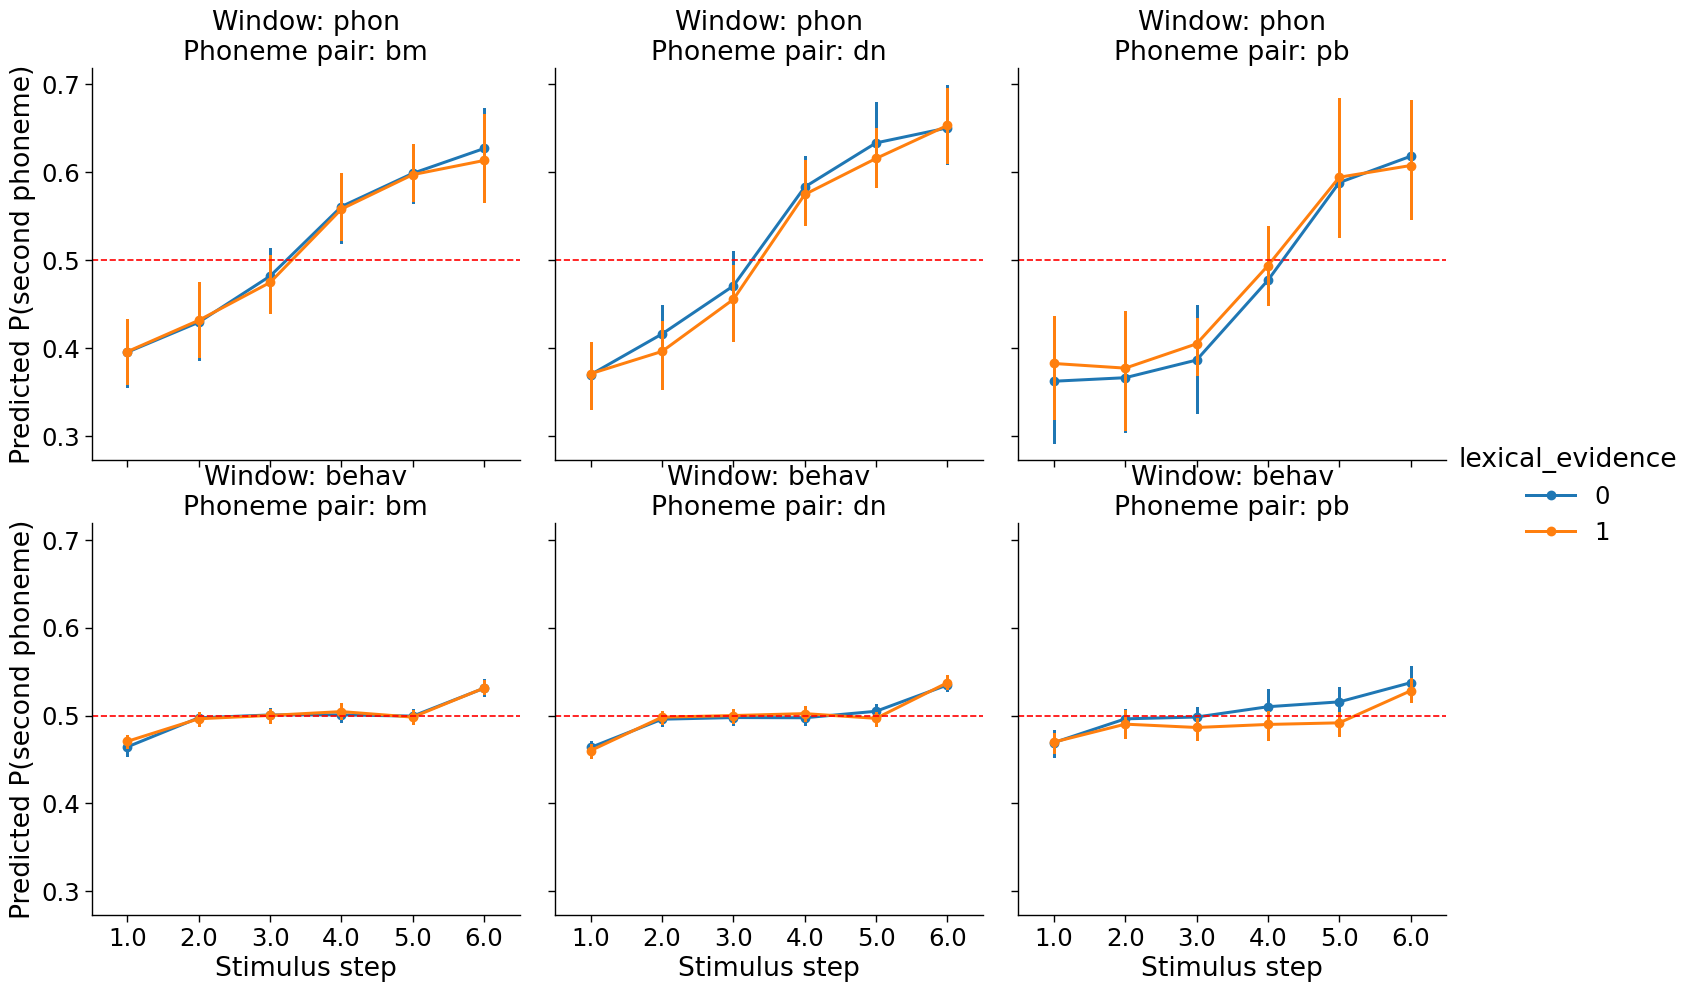

In [191]:
g = sns.catplot(data=plot_phon_df.to_pandas(),
                x="resampled", y="decoder_proba", hue="lexical_evidence",
                col="phoneme_pair", col_order=phoneme_pair_order,
                row="source", row_order=["phon", "behav"],
                kind="point", units="site")
g.set_axis_labels("Stimulus step", "Predicted P(second phoneme)")
g.set_titles(template="Window: {row_name}\nPhoneme pair: {col_name}")

for ax in g.axes.flat:
    ax.axhline(0.5, color="red", linestyle="--")

In [192]:
# compute phonetic accuracy per source and resampled, within fold
phon_acc = (plot_phon_df
 .with_columns(
     ((pl.col("decoder_target") == 1) == (pl.col("decoder_proba") >= 0.5))
     .cast(pl.Float32).alias("correct")
 )
 .group_by(["source", "site", "subject", "electrode_idx", "phoneme_pair", "lexical_evidence", "resampled", "fold"])
 .agg(pl.col("correct").mean().alias("accuracy")))

In [194]:
phon_acc_change = (phon_acc
    .pivot(
        values="accuracy",
        index=["site", "subject", "electrode_idx", "phoneme_pair",
            "resampled", "lexical_evidence", "fold"],
        on="source",
        aggregate_function="first"
    )
    .drop_nulls(["phon", "behav"])
    .with_columns(
        (pl.col("phon") - pl.col("behav")).alias("acc_diff")
    )
)

In [ ]:
# # compute phonetic accuracy per source and resampled, within fold
# phon_acc = plot_phon_df.groupby(["source", "site", "subject", "electrode_idx", "phoneme_pair", "resampled", "lexical_evidence", "smin", "smax", "fold"]) \
#     .progress_apply(lambda xs: accuracy_score(xs.decoder_target == 1, xs.decoder_proba > 0.5)) \
#     .rename("accuracy").reset_index()

  0%|          | 0/12120 [00:00<?, ?it/s]

In [ ]:
# # Pivot wider and get difference in accuracy depending on phon source vs behav source
# assert phon_acc.groupby(["site", "subject", "electrode_idx", "phoneme_pair", "resampled", "lexical_evidence", "fold"]).size().max() <= 2

# # NB we are doing dropna here -- so those phon sites which are predictive of phon but
# # not predictive of behav aren't included in the comparison
# phon_acc_change = phon_acc.pivot_table(
#     index=["site", "subject", "electrode_idx", "phoneme_pair", "resampled", "lexical_evidence", "fold"],
#     columns="source",
#     values="accuracy").dropna().assign(acc_diff=lambda df: df.phon - df.behav)

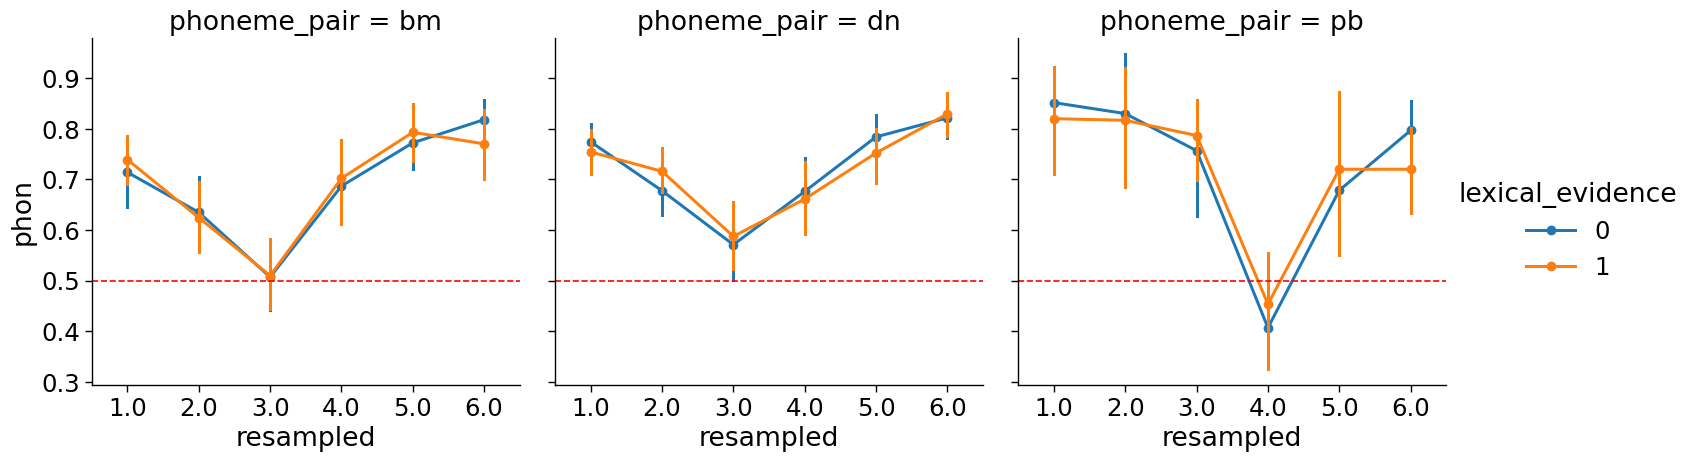

In [195]:
g = sns.catplot(data=phon_acc_change.to_pandas(),
                x="resampled", y="phon", hue="lexical_evidence",
                col="phoneme_pair", col_order=phoneme_pair_order,
                kind="point", units="site")
for ax in g.axes.flat:
    ax.axhline(0.5, color="red", linestyle="--")

In [92]:
# from scipy.stats import ttest_1samp
# phon_acc_change.groupby(["phoneme_pair", "resampled", "lexical_evidence"]) \
#     .apply(lambda xs: pd.Series(ttest_1samp(xs["phon"], popmean=0.5), index=["t_stat", "p_value"])).sort_values("p_value")

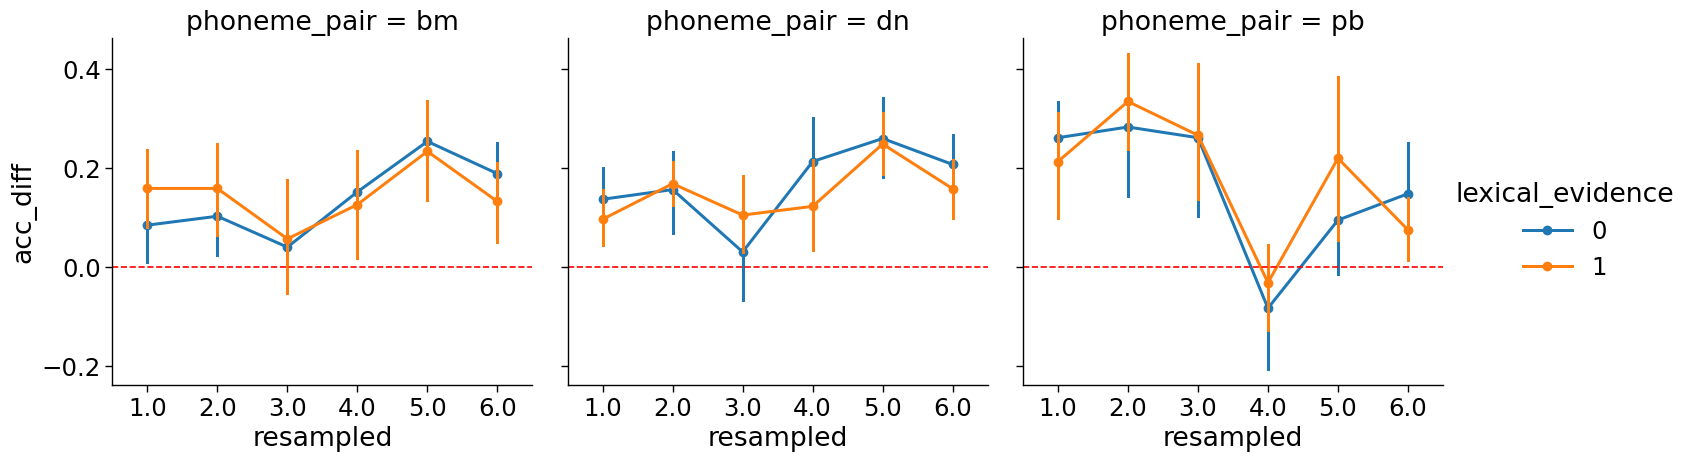

In [196]:
g = sns.catplot(data=phon_acc_change.to_pandas(),
                x="resampled", y="acc_diff", hue="lexical_evidence",
                col="phoneme_pair", col_order=phoneme_pair_order,
                kind="point", units="site")
for ax in g.axes.flat:
    ax.axhline(0, color="red", linestyle="--")

In [94]:
# from scipy.stats import ttest_1samp
# phon_acc_change.groupby(["phoneme_pair", "resampled", "lexical_evidence"]) \
#     .apply(lambda xs: pd.Series(ttest_1samp(xs["acc_diff"], popmean=0), index=["t_stat", "p_value"])).sort_values("p_value")

## Behav prediction

In [197]:
plot_phon_behav_keys = phon_peaks_df.select(["subject", "electrode_idx", "phoneme_pair", "smin", "smax"])
plot_phon_behav_df = plot_phon_behav_keys.join(
    behav_pred_df,
    on=["subject", "electrode_idx", "phoneme_pair", "smin", "smax"],
    how="left")
missing_phon_behav = plot_phon_behav_df.filter(pl.col("full_decoder_proba").is_null())
if missing_phon_behav.height > 0:
    L.warning(f"Found {missing_phon_behav.height} phonetic peak sites with no matching behavioral predictions")
    L.warning(missing_phon_behav.select(["subject", "electrode_idx", "phoneme_pair", "smin", "smax"]))

plot_behav_behav_keys = behav_peaks_df.select(
    ["subject", "electrode_idx", "phoneme_pair", "word_end", "smin", "smax"]
)
plot_behav_behav_df = plot_behav_behav_keys.join(
    behav_pred_df,
    on=["subject", "electrode_idx", "phoneme_pair", "word_end", "smin", "smax"],
    how="left"
)
missing_behav_behav = plot_behav_behav_df.filter(pl.col("full_decoder_proba").is_null())
if missing_behav_behav.height > 0:
    L.warning(f"Found {missing_behav_behav.height} behavioral peak sites with no matching behavioral predictions")
    L.warning(missing_behav_behav.select(["subject", "electrode_idx", "phoneme_pair", "word_end", "smin", "smax"]))

2026-01-29 14:56:10.126 | WARNING  | __main__:<module>:8 - Found 2 phonetic peak sites with no matching behavioral predictions
2026-01-29 14:56:10.128 | WARNING  | __main__:<module>:9 - shape: (2, 5)
┌─────────┬───────────────┬──────────────┬──────┬──────┐
│ subject ┆ electrode_idx ┆ phoneme_pair ┆ smin ┆ smax │
│ ---     ┆ ---           ┆ ---          ┆ ---  ┆ ---  │
│ enum    ┆ i64           ┆ enum         ┆ i64  ┆ i64  │
╞═════════╪═══════════════╪══════════════╪══════╪══════╡
│ EC282   ┆ 117           ┆ dn           ┆ 55   ┆ 70   │
│ EC282   ┆ 117           ┆ bm           ┆ 55   ┆ 70   │
└─────────┴───────────────┴──────────────┴──────┴──────┘


In [198]:
plot_behav_df = pl.concat(
    [
        plot_phon_behav_df.with_columns(pl.lit("phon").alias("source")),
        plot_behav_behav_df.with_columns(pl.lit("behav").alias("source")),
    ],
    how="align",
).with_columns(
    pl.concat_str(
        [pl.col("subject"), pl.col("electrode_idx").cast(pl.Utf8), pl.col("phoneme_pair")],
        separator="_"
    ).alias("site")
).join(all_md, on=["subject", "epoch_idx", "phoneme_pair", "word_end"], how="left")

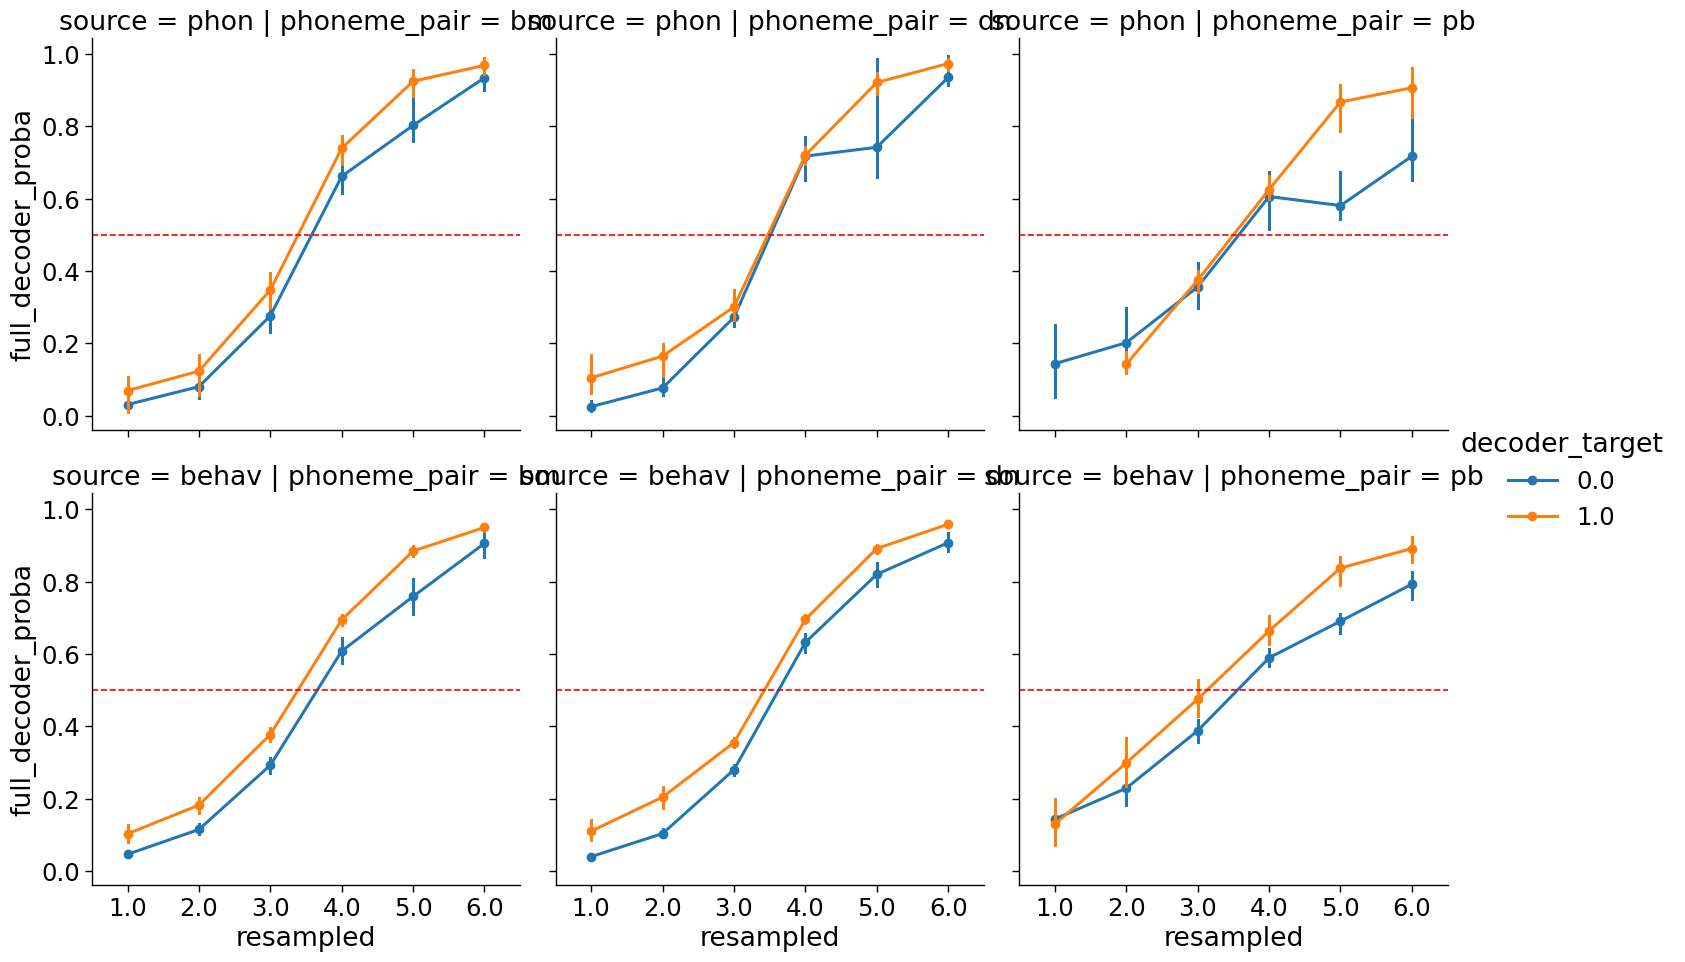

In [199]:
g = sns.catplot(data=plot_behav_df.to_pandas(),
                x="resampled", y="full_decoder_proba", hue="decoder_target",
                col="phoneme_pair", col_order=phoneme_pair_order,
                row="source", row_order=["phon", "behav"],
                kind="point", units="site")

for ax in g.axes.flat:
    ax.axhline(0.5, color="red", linestyle="--")

In [200]:
behav_roc_auc = pl_roc_auc(
    df=plot_behav_df,
    target_col="decoder_target",
    proba_col="full_decoder_proba",
    group_cols=["source", "site", "subject", "electrode_idx", "phoneme_pair", "word_end", "resampled", "smin", "smax", "fold"],
    roc_auc_name="behav_roc_auc"
).join(
    pl_roc_auc(
        df=plot_behav_df,
        target_col="decoder_target",
        proba_col="baseline_decoder_proba",
        group_cols=["source", "site", "subject", "electrode_idx", "phoneme_pair", "word_end", "resampled", "smin", "smax", "fold"],
        roc_auc_name="behav_roc_auc_baseline"),
    on=["source", "site", "subject", "electrode_idx", "phoneme_pair", "word_end", "resampled", "smin", "smax", "fold"],
    how="inner"
).with_columns(
    (pl.col("behav_roc_auc") - pl.col("behav_roc_auc_baseline")).alias("behav_roc_auc_improvement"),
    pl.concat_str(
        [pl.col("subject"), pl.col("electrode_idx").cast(pl.Utf8), pl.col("phoneme_pair")],
        separator="_"
    ).alias("site")
)

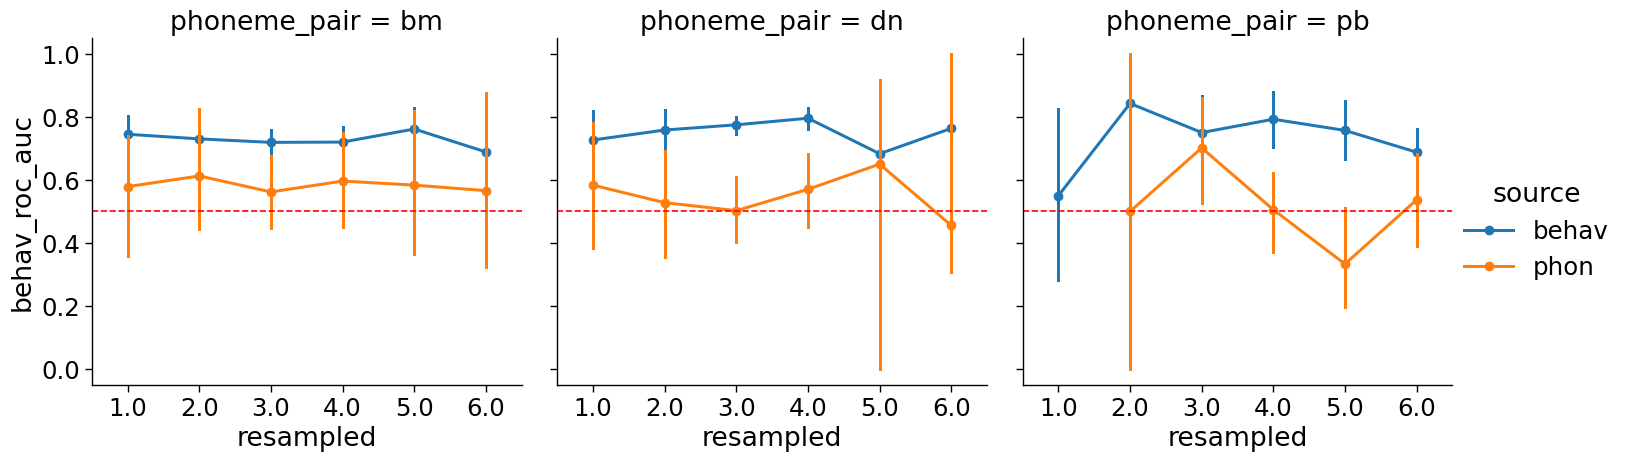

In [201]:
g = sns.catplot(data=behav_roc_auc.to_pandas(), x="resampled", y="behav_roc_auc",
                hue="source", col="phoneme_pair", col_order=phoneme_pair_order,
                kind="point", units="site")
for ax in g.axes.flat:
    ax.axhline(0.5, color="red", linestyle="--")

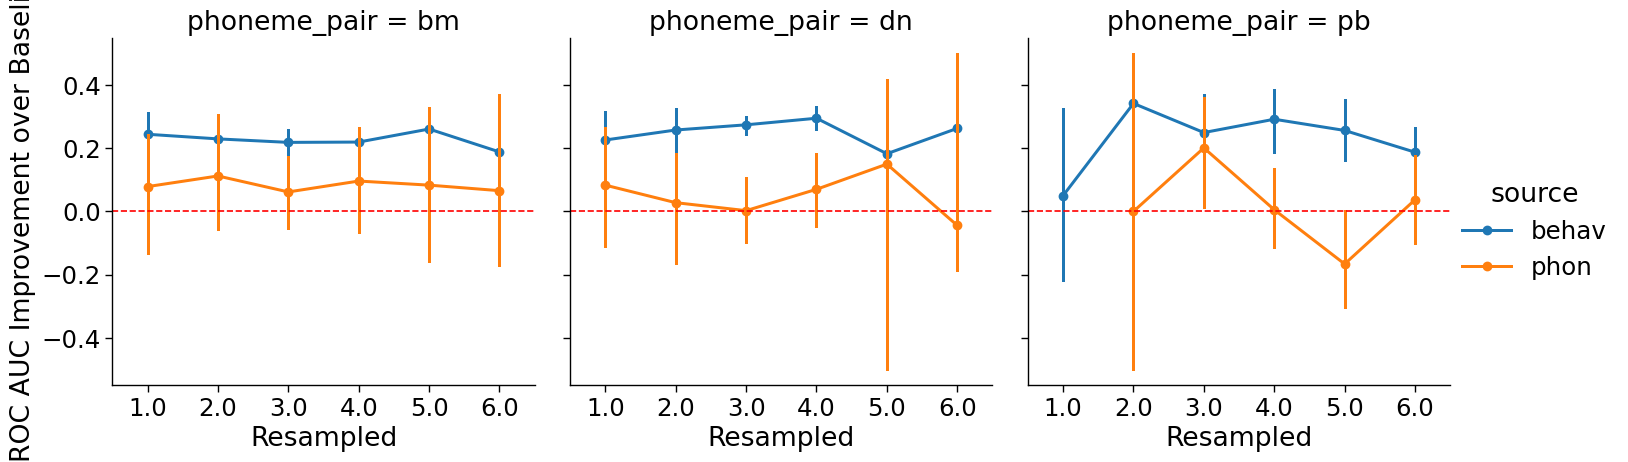

In [202]:
g = sns.catplot(data=behav_roc_auc.to_pandas(), x="resampled", y="behav_roc_auc_improvement",
                hue="source", col="phoneme_pair", col_order=phoneme_pair_order,
                kind="point", units="site")
g.set_axis_labels("Resampled", "ROC AUC Improvement over Baseline")

for ax in g.axes.flat:
    ax.axhline(0, color="red", linestyle="--")

## Dynamics

### Peak timing

In [203]:
peak_timing_plot = pl.concat([
    phon_peaks_df.with_columns(pl.lit("phon").alias("source")),
    behav_peaks_df.with_columns(pl.lit("behav").alias("source")),
], how="align").with_columns(
    (((pl.col("smin") + pl.col("smax")) / 2) / epoch_sfreq + epoch_tmin).alias("t_center")
)

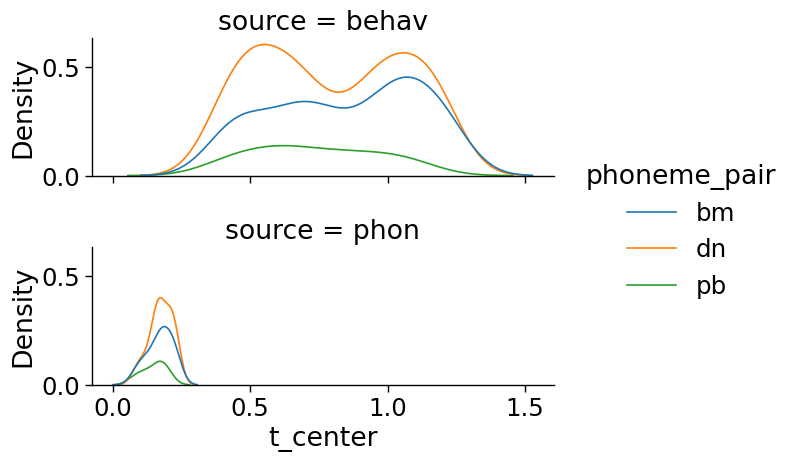

In [205]:
sns.displot(data=peak_timing_plot.to_pandas(), x="t_center",
            hue="phoneme_pair", hue_order=phoneme_pair_order,
            row="source",
            kind="kde", clip=(0, None),
            height=2.5, aspect=2.5)

### Peak timing of behavior relative to word offset

In [209]:
# behav_peak_timing_plot = behav_peaks_df.copy()
# behav_peak_timing_plot["t_center"] = ((behav_peak_timing_plot.smin + behav_peak_timing_plot.smax) / 2) / epoch_sfreq + epoch_tmin
# behav_peak_timing_plot["t_offset"] = behav_peak_timing_plot.word_end.map(OFFSET_DICT)
# behav_peak_timing_plot["t_pod"] = behav_peak_timing_plot.phoneme_pair.map(POD_dict)
# assert not behav_peak_timing_plot.t_offset.isna().any()
# behav_peak_timing_plot["t_from_offset"] = behav_peak_timing_plot.t_center - behav_peak_timing_plot.t_offset
# behav_peak_timing_plot["t_from_pod"] = behav_peak_timing_plot.t_center - behav_peak_timing_plot.t_pod

behav_peak_timing_plot = behav_peaks_df.with_columns(
    (((pl.col("smin") + pl.col("smax")) / 2) / epoch_sfreq + epoch_tmin).alias("t_center"),
    pl.col("word_end").map_elements(lambda x: OFFSET_DICT[x]).alias("t_offset"),
    pl.col("phoneme_pair").map_elements(lambda x: POD_dict[x]).alias("t_pod")
).with_columns(
    (pl.col("t_center") - pl.col("t_offset")).alias("t_from_offset"),
    (pl.col("t_center") - pl.col("t_pod")).alias("t_from_pod")
)

/tmp/ipykernel_3376297/1261438086.py:11: PolarsInefficientMapWarning: 
Expr.map_elements is significantly slower than the native expressions API.
Only use if you absolutely CANNOT implement your logic otherwise.
Replace this expression...
  - pl.col("word_end").map_elements(lambda x: ...)
with this one instead:
  + pl.col("word_end").replace_strict(OFFSET_DICT)

  pl.col("word_end").map_elements(lambda x: OFFSET_DICT[x]).alias("t_offset"),
/tmp/ipykernel_3376297/1261438086.py:12: PolarsInefficientMapWarning: 
Expr.map_elements is significantly slower than the native expressions API.
Only use if you absolutely CANNOT implement your logic otherwise.
Replace this expression...
  - pl.col("phoneme_pair").map_elements(lambda x: ...)
with this one instead:
  + pl.col("phoneme_pair").replace_strict(POD_dict)

  pl.col("phoneme_pair").map_elements(lambda x: POD_dict[x]).alias("t_pod")
sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpr

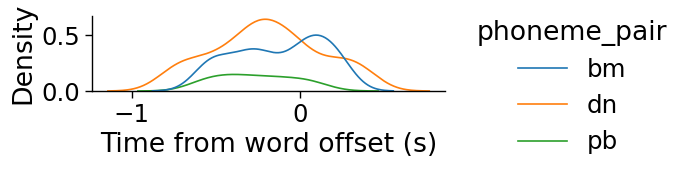

In [210]:
g = sns.displot(data=behav_peak_timing_plot.to_pandas(), x="t_from_offset",
                hue="phoneme_pair", hue_order=phoneme_pair_order,
                # hue="subject",
                kind="kde",
                height=2, aspect=2.5)
g.set_axis_labels("Time from word offset (s)", "Density")

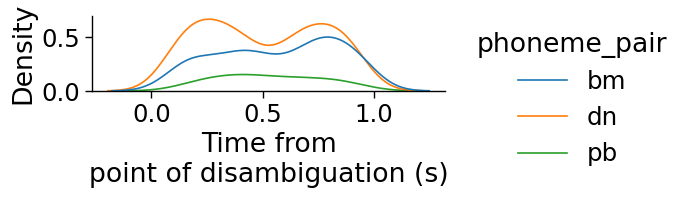

In [211]:
g = sns.displot(data=behav_peak_timing_plot.to_pandas(), x="t_from_pod",
                hue="phoneme_pair", hue_order=phoneme_pair_order,
                # hue="subject",
                kind="kde",
                height=2, aspect=2.5)
g.set_axis_labels("Time from\npoint of disambiguation (s)", "Density")

### Performance relative to peak

In [257]:
phon_relative_df = pd.merge(
    phon_peaks_df, phon_roc_auc_mean_df,
    on=["subject", "electrode_idx", "phoneme_pair"],
    suffixes=("_peak", ""),
    how="left")
phon_relative_df["smin_relative"] = phon_relative_df.smin - phon_relative_df.smin_peak
phon_relative_df["smax_relative"] = phon_relative_df.smax - phon_relative_df.smax_peak
phon_relative_df["tmax_relative"] = phon_relative_df.smax_relative / epoch_sfreq
phon_relative_df["roc_auc_relative"] = phon_relative_df.phon_roc_auc / phon_relative_df.phon_roc_auc_peak
phon_relative_df = phon_relative_df[(phon_relative_df.smin_relative >= -relative_performance_swidth) &
                                    (phon_relative_df.smax_relative <= relative_performance_swidth) &
                                    (phon_relative_df.phon_roc_auc > 0.5)]

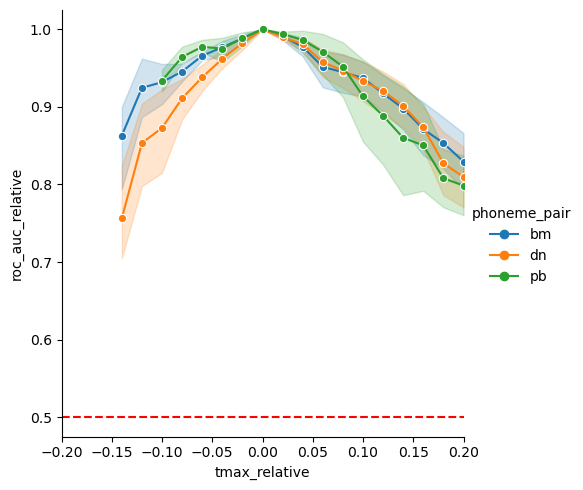

In [258]:
g = sns.relplot(data=phon_relative_df, x="tmax_relative", y="roc_auc_relative",
                hue="phoneme_pair", kind="line", marker="o")
for ax in g.axes.flat:
    ax.axhline(0.5, color="red", linestyle="--")
    ax.set_xlim(-relative_performance_twidth, relative_performance_twidth)

In [259]:
behav_relative_df = pd.merge(
    behav_peaks_df, behav_roc_auc_mean_df,
    on=["subject", "electrode_idx", "phoneme_pair", "word_end"],
    suffixes=("_peak", ""),
    how="left")
behav_relative_df["smin_relative"] = behav_relative_df.smin - behav_relative_df.smin_peak
behav_relative_df["smax_relative"] = behav_relative_df.smax - behav_relative_df.smax_peak
behav_relative_df["tmax_relative"] = behav_relative_df.smax_relative / epoch_sfreq
behav_relative_df["roc_auc_relative"] = behav_relative_df.behav_roc_auc_improvement / behav_relative_df.behav_roc_auc_improvement_peak
behav_relative_df = behav_relative_df[(behav_relative_df.smin_relative >= -relative_performance_swidth) &
                                      (behav_relative_df.smax_relative <= relative_performance_swidth) &
                                      (behav_relative_df.behav_roc_auc_improvement > 0)]

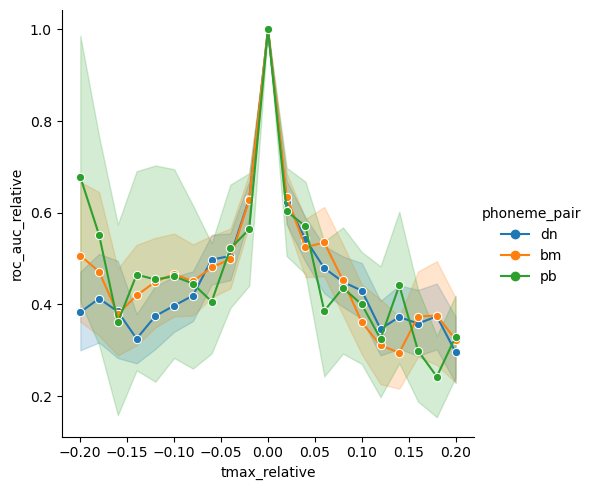

In [260]:
g = sns.relplot(data=behav_relative_df, x="tmax_relative", y="roc_auc_relative",
                hue="phoneme_pair",
                kind="line", marker="o")

## Zoomout: reproduce overall transfer result

### Phon prediction

In [291]:
phon_roc_auc_mean_df

,subject,electrode_idx,phoneme_pair,smin,smax,phon_roc_auc
0,EC243,85,bm,41,56,0.582542
1,EC243,85,bm,43,58,0.554803
2,EC243,85,bm,45,60,0.583690
3,EC243,85,bm,47,62,0.553887
4,EC243,85,bm,49,64,0.594493
...,...,...,...,...,...,...
23833,EC287,199,pb,147,162,0.542773
23834,EC287,199,pb,149,164,0.544423
23835,EC287,199,pb,151,166,0.545443
23836,EC287,199,pb,153,168,0.527235


In [293]:
plot_behav_phon_keys

,subject,electrode_idx,phoneme_pair,smin,smax,word_end
0,EC243,85,dn,105,120,desolate
1,EC243,85,dn,103,118,necessary
2,EC243,86,dn,111,126,desolate
3,EC243,86,dn,75,90,necessary
4,EC243,87,bm,83,98,bountiful
...,...,...,...,...,...,...
327,EC287,185,dn,91,106,necessary
328,EC287,190,dn,123,138,desolate
329,EC287,190,dn,79,94,necessary
330,EC287,199,pb,91,106,beneficial


In [ ]:
phon_roc_auc_comparison_df = pd.concat([
    pd.merge(plot_phon_phon_keys, phon_roc_auc_searchlight_df,
             on=["subject", "electrode_idx", "phoneme_pair", "smin", "smax"],
             how="left",
    ).assign(source="phon"),
    pd.merge(plot_behav_phon_keys, phon_roc_auc_searchlight_df,
             on=["subject", "electrode_idx", "phoneme_pair", "smin", "smax"],
             how="left",
    ).assign(source="behav")
])

phon_roc_auc_comparison_df["site"] = phon_roc_auc_comparison_df.subject.astype(str) + "_" + phon_roc_auc_comparison_df.electrode_idx.astype(str) + "_" + phon_roc_auc_comparison_df.phoneme_pair.astype(str)

NameError: name 'plot_phon_phon_keys' is not defined

In [ ]:
phon_roc_auc_comparison_df

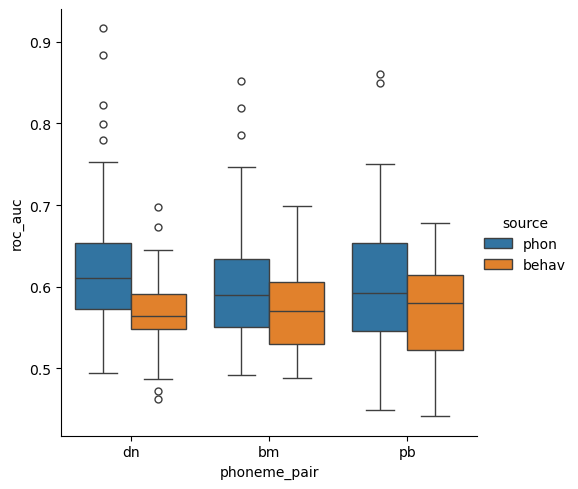

In [ ]:
sns.catplot(data=phon_roc_auc_comparison_df, x="phoneme_pair", y="roc_auc",
            hue="source", hue_order=["phon", "behav"], kind="box")

    source subject  electrode_idx phoneme_pair  smin  smax   roc_auc word_end
0    behav   EC243             85           dn   269   284  0.472608       NA
167   phon   EC243             85           dn    40    70  0.527249       NA
2
2
    source subject  electrode_idx phoneme_pair  smin  smax   roc_auc word_end
1    behav   EC243             86           dn   225   240  0.550540       NA
168   phon   EC243             86           dn    40    70  0.540404       NA
2
2
    source subject  electrode_idx phoneme_pair  smin  smax   roc_auc word_end
3    behav   EC243             87           dn   249   264  0.490355       NA
170   phon   EC243             87           dn    40    70  0.670484       NA
2
2
    source subject  electrode_idx phoneme_pair  smin  smax   roc_auc word_end
4    behav   EC243             96           dn   245   260  0.561921       NA
171   phon   EC243             96           dn    40    70  0.543517       NA
2
2
    source subject  electrode_idx phoneme_pair  

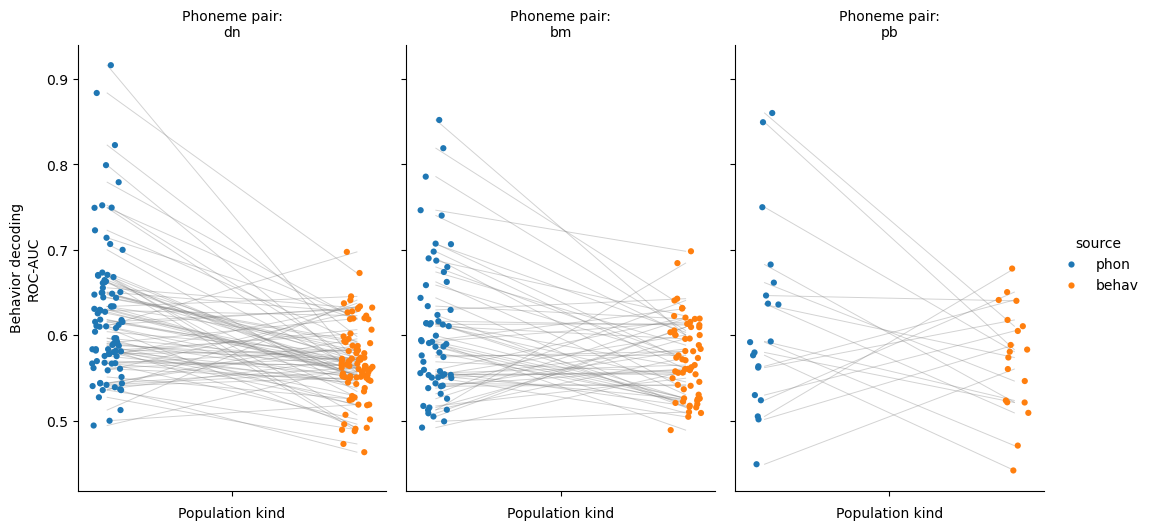

In [97]:
from src.viz import spaghetti_plot
spaghetti_plot(phon_roc_auc_overall.assign(word_end="NA"),
               y="roc_auc", by1="phon", by2="behav", by="source",
               col="phoneme_pair")

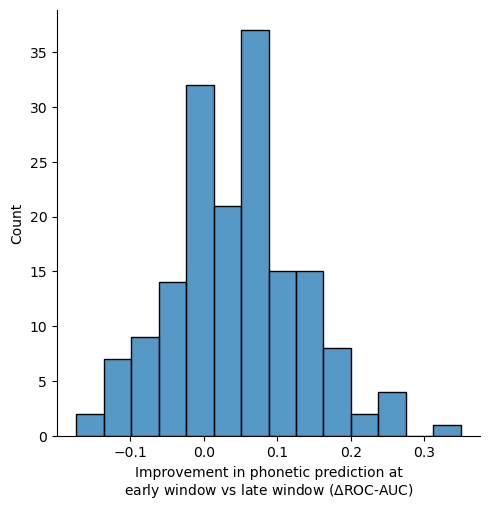

In [98]:
g = sns.displot(x="source_diff", data=phon_roc_auc_overall.pivot_table(
    index=["subject", "electrode_idx", "phoneme_pair"],
    columns="source",
    values="roc_auc"
).dropna().assign(source_diff=lambda df: df.phon - df.behav))
g.set_axis_labels("Improvement in phonetic prediction at\nearly window vs late window ($\Delta$ROC-AUC)")

### Behav prediction

In [127]:
# summarize behavior prediction roc-auc
# keep the latest window of results for each behavior site
behav_roc_auc_overall_behav = plot_behav_behav_df.groupby(["subject", "electrode_idx", "smin", "smax", "phoneme_pair", "word_end"]) \
    .progress_apply(lambda xs: roc_auc_score(xs.decoder_target, xs.full_decoder_proba)) \
    .rename("roc_auc").reset_index() \
    .sort_values("smax", ascending=False) \
    .groupby(["subject", "electrode_idx", "phoneme_pair", "word_end"]).first().reset_index()

  0%|          | 0/653 [00:00<?, ?it/s]

In [128]:
# summarize behavior prediction roc-auc at phon windows
behav_roc_auc_overall_phon = plot_phon_behav_df.groupby(["subject", "electrode_idx", "smin", "smax", "phoneme_pair", "word_end"]) \
    .progress_apply(lambda xs: roc_auc_score(xs.decoder_target, xs.full_decoder_proba)) \
    .rename("roc_auc").reset_index() \
    .sort_values("smax", ascending=False) \
    .groupby(["subject", "electrode_idx", "phoneme_pair", "word_end"]).first().reset_index()

  0%|          | 0/332 [00:00<?, ?it/s]

In [129]:
# only retain phon results for those sites that appeared in behav results
behav_roc_auc_overall_phon = pd.merge(
    behav_roc_auc_overall_phon,
    behav_roc_auc_overall_behav[["subject", "electrode_idx", "phoneme_pair", "word_end"]],
    on=["subject", "electrode_idx", "phoneme_pair", "word_end"],
    how="inner"
)

In [135]:
# Also compute ROC-AUC for the baseline behavior decoder
behav_roc_auc_overall_baseline = pd.merge(plot_behav_phon_keys, behav_ensemb_df,
         on=["subject", "electrode_idx", "phoneme_pair", "word_end", "smin", "smax"],
         how="inner") \
    .groupby(["subject", "electrode_idx", "phoneme_pair", "word_end", "smin", "smax"]) \
    .progress_apply(lambda xs: roc_auc_score(xs.decoder_target, xs.baseline_decoder_proba)) \
    .rename("roc_auc").reset_index()

  0%|          | 0/331 [00:00<?, ?it/s]

In [136]:
behav_roc_auc_overall = pd.concat([
    behav_roc_auc_overall_behav.assign(source="behav"),
    behav_roc_auc_overall_phon.assign(source="phon"),
    behav_roc_auc_overall_baseline.assign(source="baseline")
], ignore_index=True)

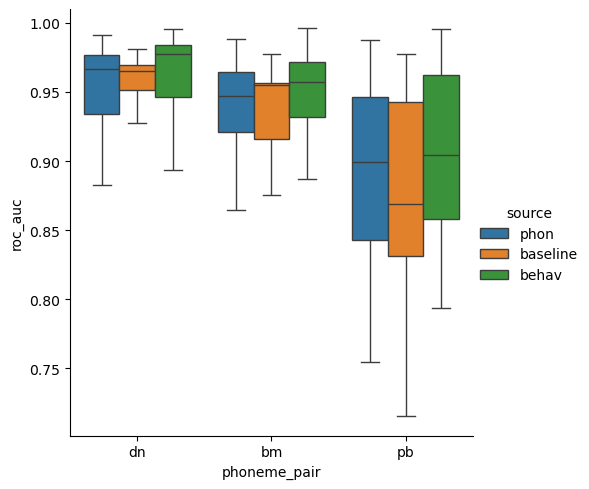

In [137]:
sns.catplot(data=behav_roc_auc_overall, x="phoneme_pair", y="roc_auc",
            hue="source", hue_order=["phon", "baseline", "behav"], kind="box",
            showfliers=False)

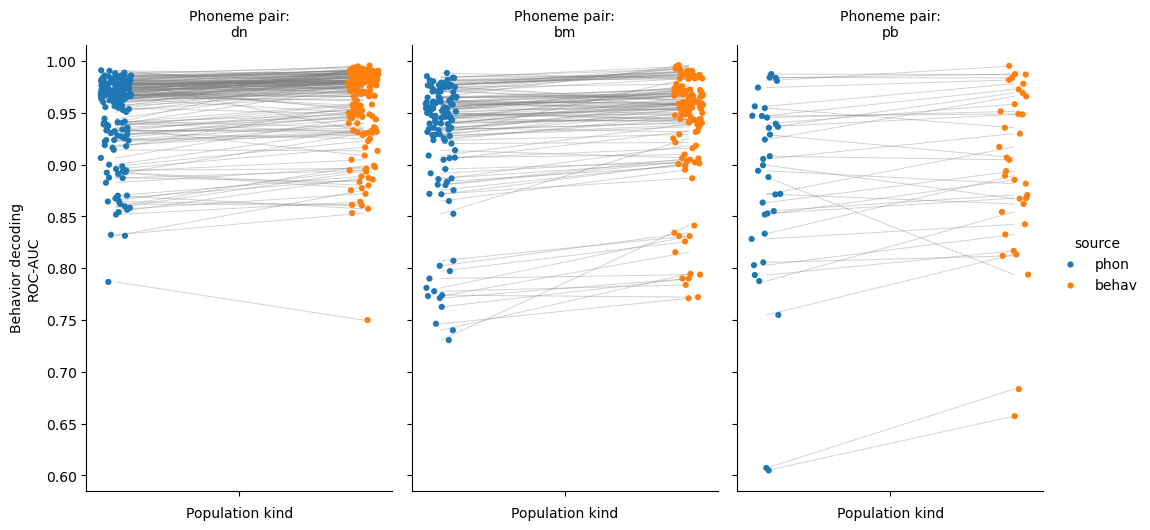

In [139]:
spaghetti_plot(behav_roc_auc_overall.query("source in ['phon', 'behav']"),
               y="roc_auc", by1="phon", by2="behav", by="source",
               col="phoneme_pair")

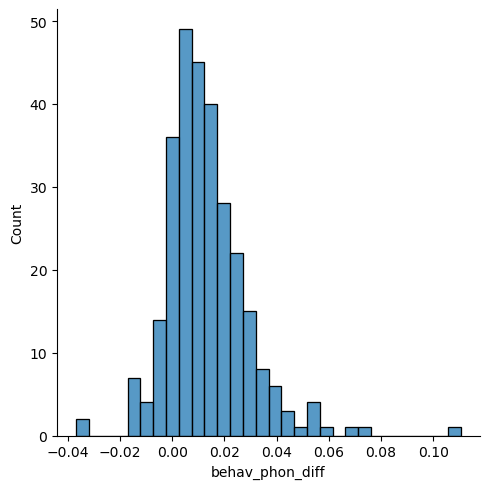

In [140]:
sns.displot(x="behav_phon_diff", data=behav_roc_auc_overall.pivot_table(
    index=["subject", "electrode_idx", "phoneme_pair", "word_end"],
    columns="source",
    values="roc_auc"
).dropna().assign(behav_baseline_diff=lambda df: df.behav - df.baseline,
                  behav_phon_diff=lambda df: df.behav - df.phon).query("behav_baseline_diff > 0"))

## Zoomin

In [222]:
pd.merge(phon_sum_df,
         behav_sum_df[["subject", "electrode_idx", "phoneme_pair", "word_end", "diff"]].rename(columns={"diff": "behav_improvement"}),
         on=["subject", "electrode_idx", "phoneme_pair"], suffixes=("_phon", "_behav")) \
    .sort_values("roc_auc", ascending=False)[["subject", "electrode_idx", "phoneme_pair", "word_end", "roc_auc", "behav_improvement"]] \
    .drop_duplicates(["subject", "electrode_idx", "phoneme_pair", "word_end"]) \
    .head(30)

,subject,electrode_idx,phoneme_pair,word_end,roc_auc,behav_improvement
76,EC250,216,bm,bountiful,0.952,0.010480
77,EC250,216,bm,mountains,0.952,0.014480
188,EC253,21,bm,bountiful,0.950,0.010984
191,EC253,21,bm,mountains,0.950,0.005817
192,EC253,21,pb,beneficial,0.942,0.007932
195,EC253,21,pb,penecillin,0.942,0.000707
83,EC250,215,pb,penecillin,0.938,-0.067083
82,EC250,215,pb,beneficial,0.938,0.003864
84,EC250,215,dn,desolate,0.934,0.009903
85,EC250,215,dn,necessary,0.934,0.010868


In [210]:
def zoomin(subject, electrode_idx, phoneme_pair):
    def keep_top_smax(rows):
        keep_smax = rows.smax.max()
        return rows.query(f"smax == {keep_smax}")

    # phonetic predictions
    subplot_phon_phon_df = plot_phon_phon_df.reset_index().query(f"electrode_idx== {electrode_idx} and subject == '{subject}' and phoneme_pair == '{phoneme_pair}'")
    subplot_behav_phon_df = plot_behav_phon_df.reset_index().query(f"electrode_idx== {electrode_idx} and subject == '{subject}' and phoneme_pair == '{phoneme_pair}'")
    # keep only one behavioral window (the latest one); nb this may be different for the two word ends
    subplot_behav_phon_df = subplot_behav_phon_df.groupby("word_end").apply(keep_top_smax).reset_index(drop=True)

    # behav predictions
    subplot_behav_behav_df = plot_behav_behav_df.reset_index().query(f"electrode_idx== {electrode_idx} and subject == '{subject}' and phoneme_pair == '{phoneme_pair}'")
    subplot_phon_behav_df = plot_phon_behav_df.reset_index().query(f"electrode_idx== {electrode_idx} and subject == '{subject}' and phoneme_pair == '{phoneme_pair}'")
    # keep only one behavioral window (the latest one); nb this may be different for the two word ends
    subplot_behav_behav_df = subplot_behav_behav_df.groupby("word_end").apply(keep_top_smax).reset_index(drop=True)

    assert subplot_phon_phon_df.smin.nunique() == 1
    assert subplot_behav_phon_df.groupby("word_end").smin.nunique().max() == 1
    assert subplot_behav_behav_df.groupby("word_end").smin.nunique().max() == 1
    assert subplot_phon_behav_df.smin.nunique() == 1

    subplot_phon_df = pd.concat([
        subplot_phon_phon_df.assign(source="phon"),
        subplot_behav_phon_df.assign(source="behav")
    ])
    subplot_behav_df = pd.concat([
        subplot_phon_behav_df.assign(source="phon"),
        subplot_behav_behav_df.assign(source="behav")
    ])

    print("Phonetic window:", subplot_phon_phon_df.smin.min(), "-", subplot_phon_phon_df.smax.max())
    print("Behavioral window:", subplot_behav_behav_df.smin.min(), "-", subplot_behav_behav_df.smax.max())

    sub_phon_acc_change = phon_acc_change.query(f"electrode_idx== {electrode_idx} and subject == '{subject}' and phoneme_pair == '{phoneme_pair}'")
    sub_behav_roc_auc = behav_roc_auc.query(f"electrode_idx== {electrode_idx} and subject == '{subject}' and phoneme_pair == '{phoneme_pair}'")
    sub_behav_roc_auc_improvement = behav_roc_auc_improvement.query(f"electrode_idx== {electrode_idx} and subject == '{subject}' and phoneme_pair == '{phoneme_pair}'")

    # Also compute overall phonetic and behavioral ROC-AUC
    phon_phon_roc_auc = roc_auc_score(subplot_phon_phon_df.decoder_target, subplot_phon_phon_df.decoder_proba)
    behav_phon_roc_auc = roc_auc_score(subplot_behav_phon_df.decoder_target, subplot_behav_phon_df.decoder_proba)
    behav_behav_roc_auc = roc_auc_score(subplot_behav_behav_df.decoder_target, subplot_behav_behav_df.full_decoder_proba)
    phon_behav_roc_auc = roc_auc_score(subplot_phon_behav_df.decoder_target, subplot_phon_behav_df.full_decoder_proba)
    roc_auc_heatmap_df = pd.DataFrame({
        "source": ["phon", "phon", "behav", "behav"],
        "target": ["phon", "behav", "phon", "behav"],
        "roc_auc": [phon_phon_roc_auc, phon_behav_roc_auc, behav_phon_roc_auc, behav_behav_roc_auc]
    }).pivot(index="source", columns="target", values="roc_auc")

    f, ax = plt.subplots(figsize=(4, 4))
    sns.heatmap(roc_auc_heatmap_df, annot=True, vmin=0.5, vmax=1.0, cmap="Blues", ax=ax)

    g_phon = sns.catplot(
        data=subplot_phon_df,
        x="resampled", y="decoder_proba", hue="lexical_evidence",
        col="source", col_order=["phon", "behav"],
        kind="point", height=4)
    for ax in g_phon.axes.flat:
        ax.axhline(0.5, color="red", linestyle="--")

    g_phon_acc_change = sns.catplot(
        data=sub_phon_acc_change,
        x="resampled", y="acc_diff", hue="lexical_evidence",
        kind="point", height=3)
    g_phon_acc_change.figure.suptitle("Improvement in phonetic decoding\nat phon - behav window")
    for ax in g_phon_acc_change.axes.flat:
        ax.axhline(0, color="red", linestyle="--")

    g_behav = sns.catplot(
        data=subplot_behav_df,
        x="resampled", y="full_decoder_proba", hue="decoder_target",
        col="source", col_order=["phon", "behav"],
        kind="point", height=4)
    for ax in g_behav.axes.flat:
        ax.axhline(0.5, color="red", linestyle="--")

    g_behav_roc_auc = sns.catplot(
        data=sub_behav_roc_auc,
        x="resampled", y="roc_auc",
        hue="source", col="word_end",
        kind="point", height=3)
    g_behav_roc_auc.set_axis_labels("Resampled", "ROC AUC")
    for ax in g_behav_roc_auc.axes.flat:
        ax.axhline(0.5, color="red", linestyle="--")

    g_behav_roc_auc_improvement = sns.catplot(
        data=sub_behav_roc_auc_improvement,
        x="resampled", y="roc_auc",
        hue="source", col="word_end",
        kind="point", height=3)
    g_behav_roc_auc_improvement.set_axis_labels("Resampled", "ROC AUC Improvement\nover Baseline")
    for ax in g_behav_roc_auc_improvement.axes.flat:
        ax.axhline(0, color="red", linestyle="--")

    return g_phon, g_phon_acc_change, g_behav, g_behav_roc_auc, g_behav_roc_auc_improvement